<a href="https://colab.research.google.com/github/Daniel-EDC/StudentPerformanceModel/blob/main/HandsOn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset has 15 columns and 2392 students
df = pd.read_csv("Student_performance_data _.csv")

#Note, this is to delete Gradeclass if GPA is what I am after
df = df.drop(columns=["GradeClass"]) #It is the opposite of GPA

#Other notes: Ethnicity (0=Caucasian, 1=African American, 2=Asian, 3=Other);
#             ParentalEducation (0=None, 1=High School, 2=Some College, 3=Bachelor’s, 4=Higher); ParentalSupport (0=None, 1=Low, 2=Moderate, 3=High, 4=Very High).

# Head of dataset
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2392, 14)

Columns:
 Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA'],
      dtype='object')

Data Types:

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
dtype: object


In [ ]:
df.describe(include='all') #statistics

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [ ]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values in each Column:\n")
print(missing_values)

#no missing values

Missing Values in each Column:

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
dtype: int64


In [ ]:
print("Number of duplicate rows is:", df.duplicated().sum())# no duplicate rows

Number of duplicate rows is: 0


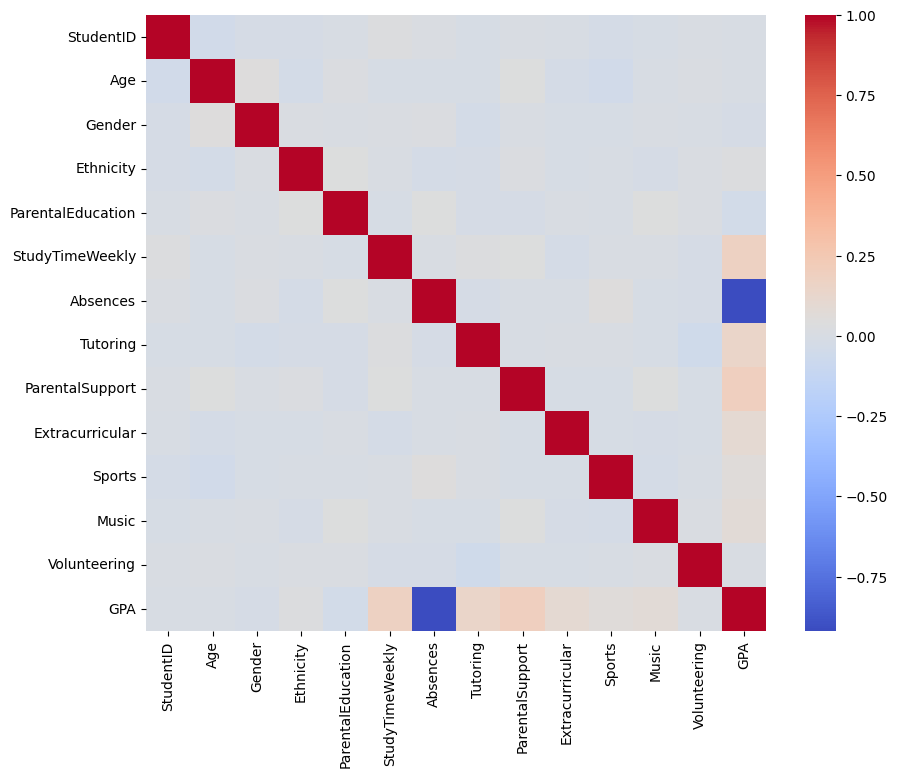

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# this is a correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

#this shows that Abscneces is blue beucase its bad(so look for no), and tutoring, studytime, and parental support are redish

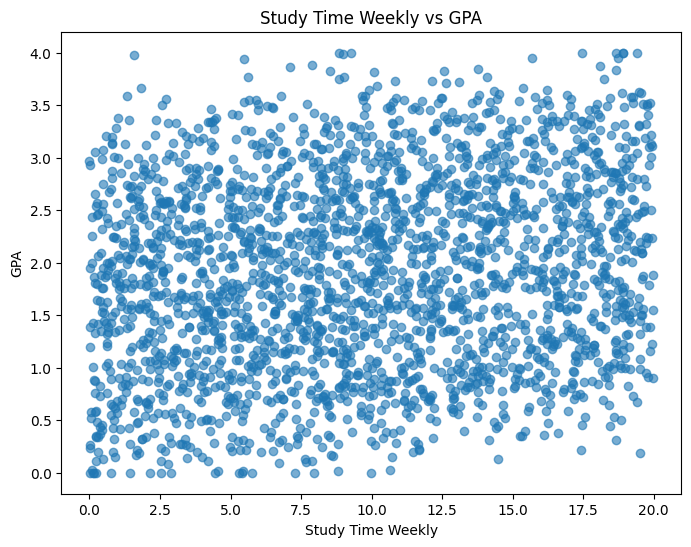

In [ ]:
#need to make a scattergraph:

import matplotlib.pyplot as plt #imot

plt.figure(figsize=(8,6))
plt.scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.6)
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.title('Study Time Weekly vs GPA')
plt.show()

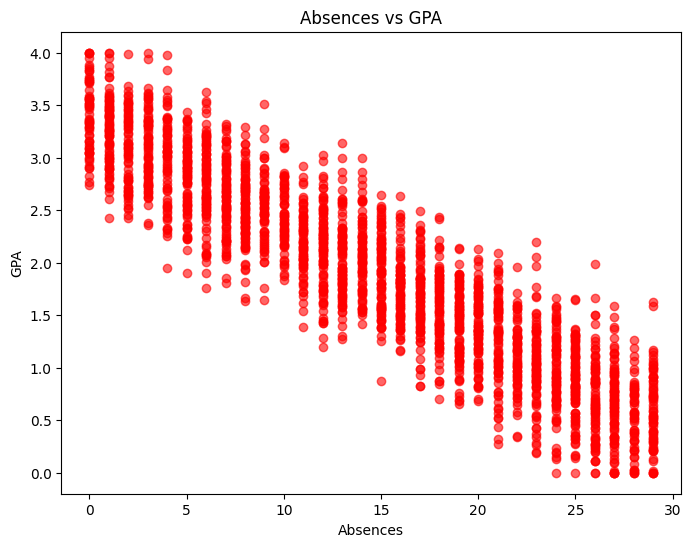

In [ ]:
# a second idea would be the absecnes one

plt.figure(figsize=(8,6))
plt.scatter(df['Absences'], df['GPA'], alpha=0.6, color='red')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Absences vs GPA')
plt.show()

#this one is better becuase it shows a relationship

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(df[['Absences']], df['GPA'])

reg.predict([[12]]) # the less, the better the GPA

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.15228762])

In [ ]:
#this is the predictions that is for the first algorithm
import pandas as pd

# load as d
d = pd.read_csv("Student_performance_data _.csv")

# Make predictions for p
p = reg.predict(d[['Absences']])

# Add predictions to dataframe
d['Predicted-GPA'] = p

# Save results
d.to_csv('predictions.csv', index=False)

# Head the results
e = pd.read_csv("predictions.csv")
e.head()
#sent to other excel sheet

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Predicted-GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,2.655492
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,3.351006
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0.767669
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,1.959978
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,1.661901


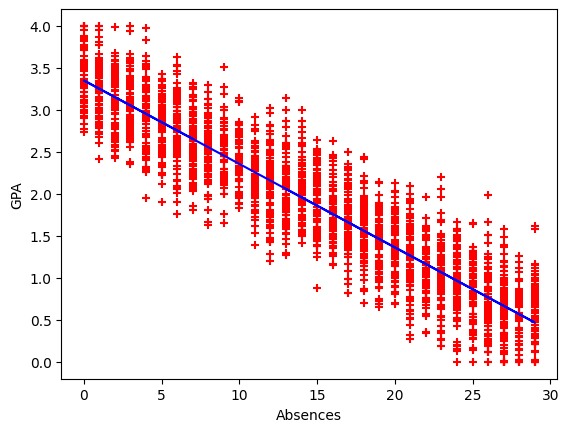

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.scatter(df['Absences'], df['GPA'], color='red', marker='+')

# Regression line
plt.plot(df['Absences'], reg.predict(df[['Absences']]), color='blue')

plt.show() #tried to change the predict, but had some problems that were hard to fix

In [ ]:
import pandas as pd

# Load your dataset (change filename if needed)
#df = pd.read_csv("students.csv")

# Features (X) and Target (y)
X = df[['Absences', 'StudyTimeWeekly']]   # chose the predictors
y = df['GPA']   # target is GPA

# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Here is the Linear Regression model
from sklearn.linear_model import LinearRegression #(again)

clf = LinearRegression()
clf.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Now for the Make predictions
y_pred = clf.predict(X_test)
y_pred

array([2.23011012, 2.05480315, 2.63572612, 2.39549638, 2.33390618,
       2.49917708, 1.00009744, 2.36448766, 0.68405599, 2.84336294,
       0.84637687, 3.61807882, 2.95884496, 3.44888003, 1.93502029,
       1.6456146 , 1.86460248, 1.0405157 , 2.22169276, 0.55795522,
       3.48229224, 0.84322537, 3.53560764, 1.46287264, 3.62092366,
       3.30161929, 2.51942477, 3.00255999, 1.40588431, 1.05663716,
       0.48413575, 0.97302661, 2.21134808, 0.63839015, 3.08103931,
       1.61672581, 3.05401315, 2.29412197, 1.38188267, 2.11409428,
       2.51103659, 3.30069797, 2.47653561, 1.11783985, 0.86802202,
       1.10888998, 1.2395566 , 1.43372103, 3.15011759, 2.56054808,
       0.91695243, 0.98885113, 2.58813616, 2.74306732, 2.33292384,
       1.25357993, 1.15569344, 1.94685525, 1.74215218, 1.27683578,
       1.37739879, 1.20598646, 0.6116817 , 1.8070934 , 2.45100034,
       2.14823182, 0.57854887, 2.98823775, 3.38131058, 2.41474979,
       1.21469068, 1.20290357, 2.02853439, 1.2996451 , 0.63963

In [ ]:
#  Check score
print("The Score: ", clf.score(X_test, y_test))

The Score:  0.8779269076534688


In [ ]:
# Need a Pass or Fail column based on GPA
df["Pass"] = np.where(df["GPA"] >= 2.5, 1, 0)

# The passs or faill
X = df.drop(columns=["GPA", "Pass"])
y = df["Pass"]

# test and train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Here is the Linear Regression model
from sklearn.linear_model import LinearRegression #(again)

clf = LinearRegression()
clf.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Now for the Make predictions
y_pred = clf.predict(X_test)
y_pred

array([ 7.19371338e-01,  2.19847432e-01, -3.23496625e-01,  3.66825268e-01,
        3.35947925e-02,  3.94730757e-01,  1.94433625e-01,  5.14947550e-01,
        8.16346230e-01,  6.73016780e-01,  7.36124735e-01, -2.30850808e-01,
        9.74277446e-02,  6.74940898e-01,  3.79798823e-01,  3.13919045e-01,
        5.90182868e-01, -2.38219246e-01,  4.40802069e-01,  5.17936482e-02,
        5.69681508e-01,  5.75714854e-01,  1.24813869e-02,  1.65074757e-01,
       -3.52983554e-02,  4.11613012e-01,  8.55872359e-01,  6.59439234e-02,
        2.72541296e-01,  2.07214180e-01,  8.31377194e-01,  2.45063963e-01,
        3.52396250e-01, -4.91115759e-02,  7.66080015e-01,  7.53607686e-01,
        6.78077895e-01,  1.64354771e-01,  7.63571674e-02,  9.15605803e-02,
        1.56307095e-01,  6.80341669e-01,  2.11061937e-01,  5.78615409e-01,
        9.49380863e-01,  3.82211668e-01,  5.57040146e-01, -2.68880700e-01,
        3.16173847e-01,  3.33026102e-01, -2.20830513e-01, -2.06214054e-01,
        7.89930987e-02, -

In [ ]:
#  Check score
print("The Score: ", clf.score(X_test, y_test))

The Score:  0.5727013917130265


In [ ]:
from sklearn.metrics import classification_report

#print(classification_report(y_test, y_pred) )

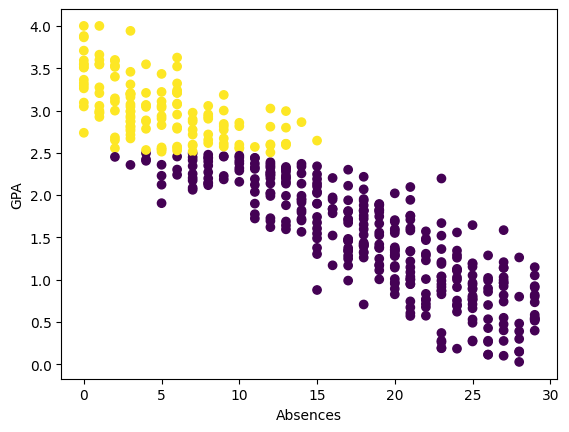

In [ ]:
# Actual Pass/Fail
plt.scatter(df.loc[X_test.index, "Absences"], df.loc[X_test.index, "GPA"], c=y_test)
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

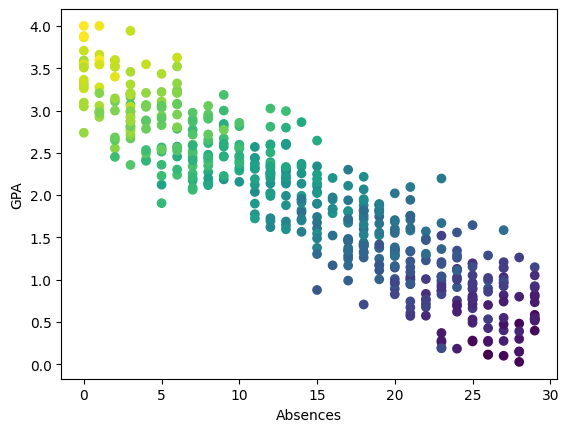

In [ ]:
# The Predicted Pass/Fail
plt.scatter(df.loc[X_test.index, "Absences"], df.loc[X_test.index, "GPA"], c=y_pred)
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm

array([[310,  31],
       [ 47,  91]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred) )

NameError: name 'y_test' is not defined